In [8]:
import os
import gymnasium as gym
import ale_py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import DQN
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.callbacks import EvalCallback
import pandas as pd
import torch
torch.set_num_threads(4)

import warnings
warnings.filterwarnings("ignore")

In [9]:
if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device("mps")

In [10]:
# Явная регистрация сред Atari
gym.register_envs(ale_py)

In [11]:
# Создаем папки для логов и моделей
os.makedirs("logs", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("Среды Atari зарегистрированы успешно!")
print("Примеры доступных сред:", [e for e in gym.envs.registry.keys() if "ALE/Pong" in e][:2])

Среды Atari зарегистрированы успешно!
Примеры доступных сред: ['ALE/Pong-v5']


In [ ]:
# Базовые гиперпараметры
BASE_PARAMS = {
    "learning_rate": 1e-4,           
    "buffer_size": 50_000,          
    "learning_starts": 10_000,       # Сначала набираем опыт без обучения
    "batch_size": 16,                # Размер мини-батча
    "gamma": 0.99,                   
    "train_freq": 2,                 # Обучаемся каждые 4 шага
    "target_update_interval": 10_000,
    "exploration_fraction": 0.1,     # e снижается от 1.0 до 0.01 за 10% обучения
    "exploration_initial_eps": 1.0,  
    "exploration_final_eps": 0.01,   
    "max_grad_norm": 10,             
}

In [13]:
# Создание среды с обертками
def make_pong_env(seed=42):
    env = make_atari_env(
        "ALE/Pong-v5", 
        n_envs=4,
        seed=seed,
        wrapper_kwargs={"frame_skip": 4}  
    )
    env = VecFrameStack(env, n_stack=4)  
    return env


In [ ]:
# Проверка создания среды
env_test = make_pong_env(seed=42)
obs = env_test.reset()  
print(f"Среда создана успешно")
print(f"Формат наблюдения: {obs.shape}")
print(f"Пространство действий: {env_test.action_space}")
env_test.close()

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Среда создана успешно
Формат наблюдения: (4, 84, 84, 4)
Пространство действий: Discrete(6)


In [17]:
# Функция обучения с логированием результатов
def train_with_params(params_name, device, buffer_size=None, target_interval=None, total_timesteps=300_000):
    """
    Обучение DQN с заданными гиперпараметрами.
    Возвращает: шаги обучения, средние награды за эпизоды
    """
    env = make_pong_env(seed=42)

    # Копируем базовые параметры и меняем нужные
    params = BASE_PARAMS.copy()
    if buffer_size is not None:
        params["buffer_size"] = buffer_size
    if target_interval is not None:
        params["target_update_interval"] = target_interval

    model = DQN(
        "CnnPolicy",
        env,
        **params,
        verbose=0,
        tensorboard_log=f"logs/tb_{params_name}",
        device=device
    )

    # Оценка каждые 25к шагов
    eval_env = make_pong_env(seed=43)
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"models/{params_name}_best/",
        log_path=f"logs/{params_name}_eval/",
        eval_freq=50_000,
        n_eval_episodes=3,
        deterministic=True,
        render=False
    )

    print(
        f"Обучение: {params_name:20s} | buffer={params['buffer_size']:>7,} | target_update={params['target_update_interval']:>6,}")
    model.learn(total_timesteps=total_timesteps,
                callback=eval_callback, progress_bar=False)

    # Сохраняем результаты
    steps = eval_callback.evaluations_timesteps
    rewards = [np.mean(r) for r in eval_callback.evaluations_results]

    df = pd.DataFrame({"step": steps, "reward": rewards})
    df.to_csv(f"logs/{params_name}_results.csv", index=False)

    env.close()
    eval_env.close()
    return steps, rewards

In [18]:
# Эксперимент 1: Влияние размера replay buffer
print("="*80)
print("ЭКСПЕРИМЕНТ 1: Влияние размера replay buffer")
print("="*80)

results_buffer = {}
for size in [10_000, 100_000, 1_000_000]:
    steps, rewards = train_with_params(
        f"buffer_{size}", device=device, buffer_size=size, total_timesteps=200_000)
    results_buffer[size] = (steps, rewards)
    print(f"buffer_size={size:>7,} -> финальная награда: {rewards[-1]:6.2f}")

ЭКСПЕРИМЕНТ 1: Влияние размера replay buffer
Обучение: buffer_10000         | buffer= 10,000 | target_update=10,000
Eval num_timesteps=200000, episode_reward=-20.33 +/- 0.47
Episode length: 989.00 +/- 112.00
New best mean reward!
buffer_size= 10,000 -> финальная награда: -20.33
Обучение: buffer_100000        | buffer=100,000 | target_update=10,000
Eval num_timesteps=200000, episode_reward=-20.67 +/- 0.47
Episode length: 1163.67 +/- 273.44
New best mean reward!
buffer_size=100,000 -> финальная награда: -20.67
Обучение: buffer_1000000       | buffer=1,000,000 | target_update=10,000
Eval num_timesteps=200000, episode_reward=-19.67 +/- 0.94
Episode length: 1286.33 +/- 140.77
New best mean reward!
buffer_size=1,000,000 -> финальная награда: -19.67


In [19]:
# Эксперимент 2: Влияние частоты обновления target network
print("\n" + "="*80)
print("ЭКСПЕРИМЕНТ 2: Влияние частоты обновления target network")
print("="*80)

results_target = {}
for interval in [1_000, 10_000, 100_000]:
    steps, rewards = train_with_params(
        f"target_{interval}", device=device, target_interval=interval, total_timesteps=200_000)
    results_target[interval] = (steps, rewards)
    print(
        f"target_update={interval:>6,} -> финальная награда: {rewards[-1]:6.2f}")


ЭКСПЕРИМЕНТ 2: Влияние частоты обновления target network
Обучение: target_1000          | buffer= 50,000 | target_update= 1,000
Eval num_timesteps=200000, episode_reward=-21.00 +/- 0.00
Episode length: 782.67 +/- 13.20
New best mean reward!
target_update= 1,000 -> финальная награда: -21.00
Обучение: target_10000         | buffer= 50,000 | target_update=10,000
Eval num_timesteps=200000, episode_reward=-19.33 +/- 0.47
Episode length: 1256.67 +/- 96.99
New best mean reward!
target_update=10,000 -> финальная награда: -19.33
Обучение: target_100000        | buffer= 50,000 | target_update=100,000
Eval num_timesteps=200000, episode_reward=-21.00 +/- 0.00
Episode length: 824.00 +/- 0.00
New best mean reward!
target_update=100,000 -> финальная награда: -21.00


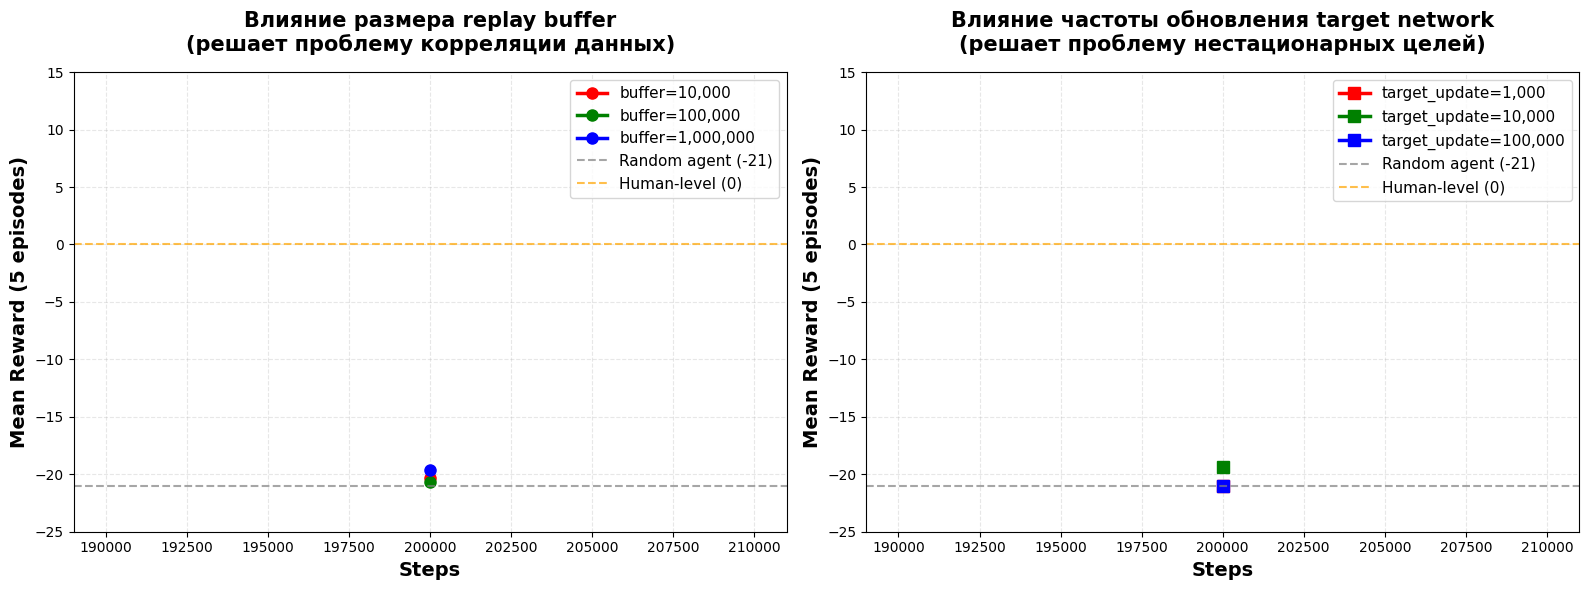

График сохранен: logs/hyperparams_comparison.png


In [20]:
# Визуализация результатов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Размер буфера
colors = ['red', 'green', 'blue']
for (size, (steps, rewards)), color in zip(results_buffer.items(), colors):
    ax1.plot(steps, rewards, label=f'buffer={size:,}',
             marker='o', linewidth=2.5, markersize=8, color=color)
ax1.axhline(y=-21, color='gray', linestyle='--',
            alpha=0.7, label='Random agent (-21)')
ax1.axhline(y=0, color='orange', linestyle='--',
            alpha=0.7, label='Human-level (0)')
ax1.set_xlabel("Steps", fontsize=14, fontweight='bold')
ax1.set_ylabel("Mean Reward (5 episodes)", fontsize=14, fontweight='bold')
ax1.set_title("Влияние размера replay buffer\n(решает проблему корреляции данных)",
              fontsize=15, fontweight='bold', pad=15)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylim(-25, 15)

# График 2: Частота обновления target network
for (interval, (steps, rewards)), color in zip(results_target.items(), colors):
    ax2.plot(steps, rewards, label=f'target_update={interval:,}',
             marker='s', linewidth=2.5, markersize=8, color=color)
ax2.axhline(y=-21, color='gray', linestyle='--',
            alpha=0.7, label='Random agent (-21)')
ax2.axhline(y=0, color='orange', linestyle='--',
            alpha=0.7, label='Human-level (0)')
ax2.set_xlabel("Steps", fontsize=14, fontweight='bold')
ax2.set_ylabel("Mean Reward (5 episodes)", fontsize=14, fontweight='bold')
ax2.set_title("Влияние частоты обновления target network\n(решает проблему нестационарных целей)",
              fontsize=15, fontweight='bold', pad=15)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_ylim(-25, 15)

plt.tight_layout()
plt.savefig("logs/hyperparams_comparison.png", dpi=200, bbox_inches='tight')
plt.show()

# Сохраняем график в логи
print("График сохранен: logs/hyperparams_comparison.png")

---
# Выводы
## 1. REPLAY BUFFER SIZE 
### Проблема: Корреляция данных = градиенты прыгают из-за последовательных скоррелированных переходов в батче.

### Наблюдения:
REPLAY BUFFER позволяет улучшить результаты, при этом нужно отметить, что увеличение не приводит к линейному улучшению, в частности при размере буффера = 100 000 результат хуже чем при 10 000, плюс увеличение накладных расходов на инференсе. Размер буфера 1e6 хоть и дает наилучший результат, но в то же время является самым дорогостоящим.

## 2. TARGET NETWORK UPDATE INTERVAL
### Проблема: Нестационарные цели = сеть гонится за убегающей целью, потому что целевые значения меняются на каждом шаге обучения.
### Наблюдения:
• Частое обновление (1к):
- Цель меняется слишком быстро, нестабильность обучения
- Агент не успевает догнать оптимальную стратегию

• Оптимальное (10к):
- Стабильные цели + своевременное обновление
- Баланс скорости и стабильности

• Редкое (100к):
- Цель застывает, медленное обучение
- Агент застревает в локальных минимумах